In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from tqdm import trange

In [49]:
def exact(yt, t0, T):
    v = eps * (sigma ** 2 * np.exp(-2*alpha*t0) + eps * (1 - np.exp(-2*alpha*t0)) / 2 / alpha) * \
        (1 - np.exp(-2*alpha*(T-t0))) / \
        (eps * (1 - np.exp(-2*alpha*T)) + 2 * alpha * sigma**2 * np.exp(-2*alpha*T))
    m = (
        eps * (np.exp(-alpha*t0) - np.exp(alpha*(t0-2*T))) * mu + \
        2 * alpha * sigma**2 * np.exp(-alpha * (T+t0)) * yt + \
        eps * (np.exp(-alpha*(T-t0)) - np.exp(-alpha*(T+t0))) * yt
    ) / (eps * (1 - np.exp(-2*alpha*T)) + 2 * alpha * sigma**2 * np.exp(-2*alpha*T))
    
    x = np.linspace(-10, 10, 10001)
    A = 1/np.sqrt(2*np.pi*sigma**2) * np.exp(-1/2/sigma**2*(x - mu) ** 2)
    B = np.sqrt(alpha/(eps * np.pi * (1-np.exp(-2*alpha*T)))) * np.exp(-alpha/eps/(1-np.exp(-2*alpha*T)) * (yt - np.exp(-alpha*T)*x) ** 2)
    C = 1/np.sqrt(np.pi * (2*np.exp(-2*alpha*T)*sigma**2 + eps*(1-np.exp(-2*alpha*T))/alpha))
    D = np.exp(-1/(2*np.exp(-2*alpha*T)*sigma**2 + eps/alpha*(1-np.exp(-2*alpha*T))) * (yt - np.exp(-alpha*T)*mu) ** 2)
    f = A * B / C / D
    
    samples = m + np.sqrt(v) * np.random.normal(size=[int(1e6)])
    
    return x, f, samples


def sampler(M, T):
    m = np.exp(-alpha * T) * mu
    sd = np.sqrt(np.exp(-2*alpha*T)*sigma**2 + eps*(1-np.exp(-2*alpha*T))/alpha/2)
    return m + sd * np.random.normal(size=M)

In [4]:
eps = 1.5
alpha = 3
sigma = 1
mu = 0
T = 1

yt = -10
x1, f1, zt1 = exact(yt, 0, T)
yt = -6
x2, f2, zt2 = exact(yt, 0, T)
yt = -3
x3, f3, zt3 = exact(yt, 0, T)
yt = 4
x4, f4, zt4 = exact(yt, 0, T)
yt = 8
x5, f5, zt5 = exact(yt, 0, T)

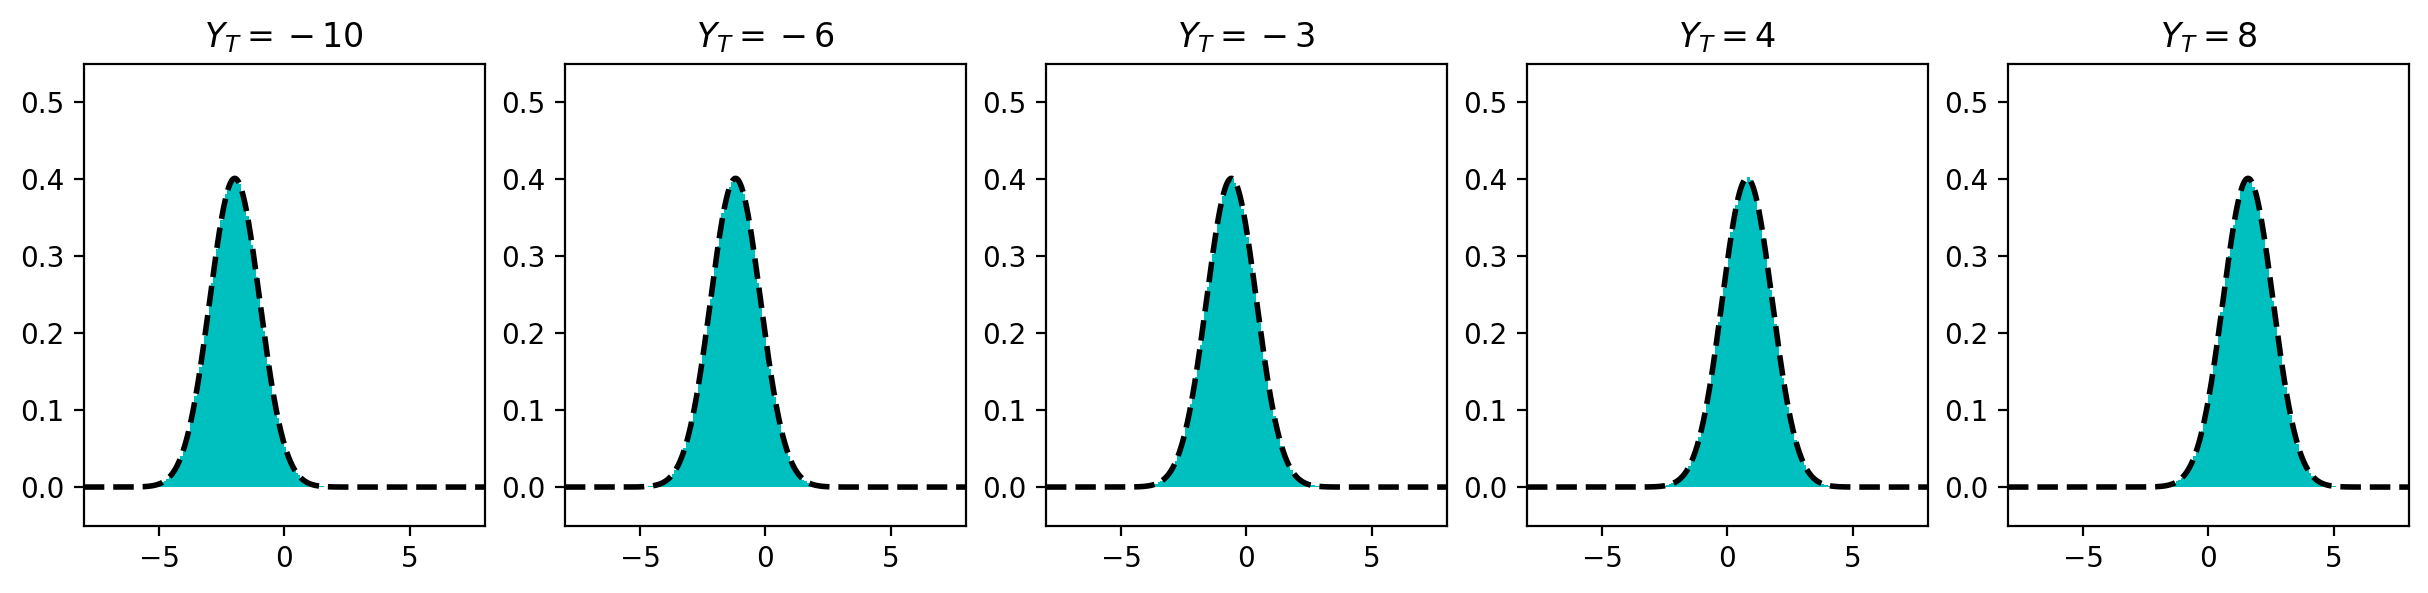

In [5]:
x = x1
fs = [f1, f2 ,f3, f4, f5]
yts = [-10, -6, -3, 4, 8]
zts = [zt1, zt2, zt3, zt4, zt5]
fig, axes = plt.subplots(1, 5, figsize=[15, 3], dpi=200)
for i in range(len(zts)):
    axes[i].hist(zts[i], bins=100, density=True, color="c")
    axes[i].plot(x, fs[i], "k--", label="The exact posterior", linewidth=2)
   
    # axes[i].set_title("$Y_T={}$".format(str(yts[i])))
    axes[i].set_title("$Y_T={}$".format(str(yts[i])))
    axes[i].set_ylim([-0.05, 0.55])
    axes[i].set_xlim([-8, 8])
fig.savefig("./figs/riccati.png")
plt.show()